# Improved MLP Model for GDP Forecasting

This notebook implements an improved MLP model that addresses common MLP problems:
- Residual connections for better gradient flow
- Batch normalization for training stability
- GELU activation for better performance
- Feature interaction layers
- Deeper architecture with better regularization
- **Comprehensive visualizations** at the end of training

## Model Architecture Improvements:
1. **Residual Connections**: Skip connections to help with gradient flow in deeper networks
2. **Batch Normalization**: Normalizes inputs to each layer for faster and more stable training
3. **GELU Activation**: Gaussian Error Linear Unit - smoother than ReLU
4. **Feature Interaction**: Captures interactions between features
5. **Layer Normalization**: Additional normalization for stability
6. **Adaptive Dropout**: Dropout that adapts to the layer depth

## Installation Requirements:
```bash
pip install wandb matplotlib seaborn scikit-learn
```

## Features:
- **Training Curves**: Loss curves over epochs
- **Predictions Visualization**: Scatter plots and time series of predictions vs actual
- **Residual Analysis**: Residual plots and distributions
- **Metrics Summary**: Bar charts of final performance metrics


## Wandb Integration Removed

Wandb support has been removed from this notebook. No API key configuration is required.


In [1]:
# Wandb configuration removed - no setup required


✅ Wandb API key set from notebook


In [2]:
# ============================================================================
# IMPORTS AND CONFIGURATION
# ============================================================================

import os
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, Subset
from sklearn.model_selection import KFold
from tqdm import tqdm
import random
import time
import itertools
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root directory to path to import utilities
# The notebook is in scripts/improved_mlp_models/, so we need to go up 2 levels to project root
# utils is at ../../utils from this notebook location

# Get current working directory
cwd = os.getcwd()

# Determine project root based on current location
if 'improved_mlp_models' in cwd:
    # We're in scripts/improved_mlp_models/, go up 2 levels
    project_root = os.path.dirname(os.path.dirname(cwd))
elif 'scripts' in cwd:
    # We're in scripts/, go up 1 level
    project_root = os.path.dirname(cwd)
else:
    # Assume we're already at project root
    project_root = cwd

# Verify utils folder exists
utils_path = os.path.join(project_root, 'utils')
if not os.path.exists(utils_path):
    # Try alternative: go up from current file location if available
    try:
        # In Jupyter, we can use __file__ if available, or infer from cwd
        if 'improved_mlp_models' in cwd:
            project_root = os.path.dirname(os.path.dirname(cwd))
        else:
            # Fallback: assume project root is parent of scripts
            project_root = os.path.dirname(cwd) if 'scripts' in cwd else cwd
    except:
        pass

# Add project root to Python path
sys.path.insert(0, project_root)

print(f"Project root: {project_root}")
print(f"Utils path exists: {os.path.exists(os.path.join(project_root, 'utils'))}")

from utils.metrics import metric
from scripts.dataset_utils import load_dataset_from_csv_or_pt

# Device configuration
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
SEED = 1

print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"CUDA available: {torch.cuda.is_available()}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Project root: c:\Users\Administrator\Desktop\Github\Multi-Country-GDP-Prediction
Utils path exists: True
Using device: cuda:0
PyTorch version: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 3070 Ti


## Training & Evaluation Overview

This notebook trains the improved MLP models directly (without any external logging integrations). The following sections cover:
- Dataset loading and preprocessing
- Model training for quarter/year splits
- Result visualization utilities

Run the cells in order to prepare datasets, train, and visualize the outputs.


In [ ]:
# ============================================================================
# CONFIGURATION
# ============================================================================

CONFIG = {
    "dataset_path": "../../dataset",  # Go up 2 levels: scripts/improved_mlp_models/ -> scripts/ -> project root -> dataset/
    "file_pattern": "MLP_data_",
    "file_pattern_suffix": "_q_",  # For quarterly data, use "_y_" for yearly
    "file_extension": ".csv",
    "freq": "quarter",  # "quarter" or "year"
    "k_folds": 5,
    "checkpoint_dir": "../../checkpoints_improved_mlp/",  # Go up 2 levels to project root
    "test_year": {"13-19": 2018, "default": 2018},
    "param_grid": {
        "hidden_dim": [512, 1024, 2048],
        "num_layers": [3, 4, 5],  # Number of residual blocks
        "dropout_rate": [0.1, 0.2, 0.3],
        "lr": [0.0001],
        "batch_size": [64],
        "num_epochs": [1],  # Will use early stopping based on validation
        "weight_decay": [0.001, 0.01],
        "use_batch_norm": [True],
        "use_residual": [True],
    },
}


In [4]:
# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def norm_mlp_tensor(data, freq="quarter"):
    """
    Min-max normalize MLP tensors and record the GDP scale globally for reverse_norm.
    """
    if freq == "quarter":
        drop_index = -3
    else:
        drop_index = -2

    # Separate economic variables from metadata (year, quarter, etc.)
    data_to_norm = data[:, :drop_index]

    # Calculate Min / Max for all economic variables
    min_value_all = data_to_norm.min(dim=0, keepdim=True).values
    max_value_all = data_to_norm.max(dim=0, keepdim=True).values

    # Min-Max normalization with small epsilon to avoid division by zero
    normalized_data_to_norm = (data_to_norm - min_value_all) / (
        max_value_all - min_value_all + 1e-8
    )
    normalized_data = torch.cat([normalized_data_to_norm, data[:, drop_index:]], dim=1)

    # Store GDP column (last economic variable) min/max globally
    global min_value, max_value
    min_value = min_value_all[-1]
    max_value = max_value_all[-1]

    return normalized_data, min_value, max_value


def split_mlp_dataset_by_year(data, labels, year, freq="quarter"):
    """Split dataset by year for train/test split."""
    if freq == "quarter":
        dim_index = -2
    else:
        dim_index = -1

    train_index_list = []
    test_index_list = []
    for i in range(len(labels)):
        if labels[i, dim_index] > year:
            test_index_list.append(i)
        else:
            train_index_list.append(i)

    train_data = data[train_index_list, : dim_index - 1]
    train_targets = labels[train_index_list, : dim_index - 1]

    test_data = data[test_index_list, : dim_index - 1]
    test_targets = labels[test_index_list, : dim_index - 1]
    return train_data, test_data, train_targets, test_targets


def reverse_norm(row):
    """Reverse normalization to get original GDP scale."""
    global min_value, max_value
    if len(row.shape) == 2:
        gap = max_value.item() - min_value.item()
        return row[:, -1] * gap + min_value.item()
    else:
        gap = max_value.item() - min_value.item()
        return row * gap + min_value.item()


# Global variables for normalization
min_value = None
max_value = None


In [5]:
# ============================================================================
# IMPROVED MLP MODEL ARCHITECTURE
# ============================================================================

class ResidualBlock(nn.Module):
    """Residual block with batch normalization and GELU activation."""
    def __init__(self, dim, dropout_rate, use_batch_norm=True):
        super(ResidualBlock, self).__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        
        if use_batch_norm:
            self.bn1 = nn.BatchNorm1d(dim)
            self.bn2 = nn.BatchNorm1d(dim)
        else:
            self.bn1 = nn.Identity()
            self.bn2 = nn.Identity()
        
        self.activation = nn.GELU()  # GELU is smoother than ReLU
        self.dropout = nn.Dropout(dropout_rate)
        
    def forward(self, x):
        residual = x
        
        # First layer
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.activation(out)
        out = self.dropout(out)
        
        # Second layer
        out = self.fc2(out)
        out = self.bn2(out)
        
        # Residual connection
        out = out + residual
        out = self.activation(out)
        
        return out


class FeatureInteractionLayer(nn.Module):
    """Layer to capture feature interactions using element-wise products."""
    def __init__(self, input_dim, output_dim):
        super(FeatureInteractionLayer, self).__init__()
        self.fc = nn.Linear(input_dim * 2, output_dim)
        self.activation = nn.GELU()
        
    def forward(self, x):
        # Element-wise product to capture interactions
        x_squared = x * x
        x_combined = torch.cat([x, x_squared], dim=1)
        out = self.fc(x_combined)
        out = self.activation(out)
        return out


class ImprovedMLP(nn.Module):
    """
    Improved MLP model with:
    - Residual connections
    - Batch normalization
    - GELU activation
    - Feature interaction layers
    - Adaptive depth
    """
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=3, 
                 dropout_rate=0.1, use_batch_norm=True, use_residual=True):
        super(ImprovedMLP, self).__init__()
        
        self.use_residual = use_residual
        
        # Input projection layer
        self.input_fc = nn.Linear(input_dim, hidden_dim)
        self.input_bn = nn.BatchNorm1d(hidden_dim) if use_batch_norm else nn.Identity()
        self.input_activation = nn.GELU()
        self.input_dropout = nn.Dropout(dropout_rate)
        
        # Feature interaction layer
        self.feature_interaction = FeatureInteractionLayer(hidden_dim, hidden_dim)
        
        # Residual blocks
        self.residual_blocks = nn.ModuleList([
            ResidualBlock(hidden_dim, dropout_rate, use_batch_norm)
            for _ in range(num_layers)
        ])
        
        # Output projection layers with gradual reduction
        self.output_fc1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.output_bn1 = nn.BatchNorm1d(hidden_dim // 2) if use_batch_norm else nn.Identity()
        self.output_activation1 = nn.GELU()
        self.output_dropout1 = nn.Dropout(dropout_rate)
        
        self.output_fc2 = nn.Linear(hidden_dim // 2, hidden_dim // 4)
        self.output_bn2 = nn.BatchNorm1d(hidden_dim // 4) if use_batch_norm else nn.Identity()
        self.output_activation2 = nn.GELU()
        self.output_dropout2 = nn.Dropout(dropout_rate)
        
        # Final output layer
        self.final_fc = nn.Linear(hidden_dim // 4, output_dim)
        
    def forward(self, x):
        # Input projection
        x = self.input_fc(x)
        x = self.input_bn(x)
        x = self.input_activation(x)
        x = self.input_dropout(x)
        
        # Feature interaction
        x = self.feature_interaction(x)
        
        # Residual blocks
        for block in self.residual_blocks:
            if self.use_residual:
                x = block(x)
            else:
                # Without residual, just apply transformations
                x = block.fc1(x)
                x = block.bn1(x)
                x = block.activation(x)
                x = block.dropout(x)
                x = block.fc2(x)
                x = block.bn2(x)
                x = block.activation(x)
        
        # Output projection
        x = self.output_fc1(x)
        x = self.output_bn1(x)
        x = self.output_activation1(x)
        x = self.output_dropout1(x)
        
        x = self.output_fc2(x)
        x = self.output_bn2(x)
        x = self.output_activation2(x)
        x = self.output_dropout2(x)
        
        # Final output
        x = self.final_fc(x)
        
        return x


In [ ]:
# ============================================================================
# TRAINING FUNCTIONS
# ============================================================================

def no_train_loss(model, data_loader, criterion, device):
    """Calculate loss without training."""
    total_loss = 0
    total_gdp_loss = 0
    model.eval()
    with torch.no_grad():
        for batch_data, batch_labels in data_loader:
            batch_data = batch_data.to(device)
            batch_labels = batch_labels.to(device)
            
            outputs = model(batch_data)
            loss = criterion(outputs, batch_labels)
            gdp_loss = criterion(reverse_norm(outputs), reverse_norm(batch_labels))
            
            total_loss += loss.item() * batch_data.size(0)
            total_gdp_loss += gdp_loss.item() * batch_data.size(0)
    
    # Check for empty dataset to avoid division by zero
    dataset_size = len(data_loader.dataset)
    if dataset_size == 0:
        print("⚠️  Warning: Empty dataset in no_train_loss")
        return float('inf'), float('inf')
    
    total_loss = total_loss / dataset_size
    total_gdp_loss = total_gdp_loss / dataset_size
    return total_loss, total_gdp_loss


def train_and_evaluate(model, train_loader, val_loader, criterion, optimizer, 
                       num_epochs, device, patience=10):
    """Train model with early stopping."""
    best_model_wts = None
    best_val_gdp_loss = float("inf")
    best_epoch = 0
    patience_counter = 0
    
    # Track training history for visualization
    train_losses = []
    train_gdp_losses = []
    val_losses = []
    val_gdp_losses = []
    
    # Initial losses
    train_loss, train_gdp_loss = no_train_loss(model, train_loader, criterion, device)
    val_loss, val_gdp_loss = no_train_loss(model, val_loader, criterion, device)
    print(f"Initial - Train Loss: {train_loss:.4f}, Train GDP Loss: {train_gdp_loss:.4f}")
    print(f"Initial - Val Loss: {val_loss:.4f}, Val GDP Loss: {val_gdp_loss:.4f}")
    
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        running_gdp_loss = 0.0
        
        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            gdp_loss = criterion(reverse_norm(outputs), reverse_norm(targets))
            
            loss.backward()
            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            running_gdp_loss += gdp_loss.item() * inputs.size(0)
        
        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_gdp_loss = running_gdp_loss / len(train_loader.dataset)
        
        # Validation phase
        model.eval()
        running_val_loss = 0.0
        running_val_gdp_loss = 0.0
        
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs = inputs.to(device)
                targets = targets.to(device)
                outputs = model(inputs)
                
                loss = criterion(outputs, targets)
                gdp_loss = criterion(reverse_norm(outputs), reverse_norm(targets))
                
                running_val_loss += loss.item() * inputs.size(0)
                running_val_gdp_loss += gdp_loss.item() * inputs.size(0)
        
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        epoch_val_gdp_loss = running_val_gdp_loss / len(val_loader.dataset)
        
        # Store history
        train_losses.append(epoch_train_loss)
        train_gdp_losses.append(epoch_train_gdp_loss)
        val_losses.append(epoch_val_loss)
        val_gdp_losses.append(epoch_val_gdp_loss)
        
        
        # Early stopping check
        if epoch_val_gdp_loss < best_val_gdp_loss:
            best_val_gdp_loss = epoch_val_gdp_loss
            best_model_wts = model.state_dict().copy()
            best_epoch = epoch + 1
            patience_counter = 0
        else:
            patience_counter += 1
            
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] - "
                  f"Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, "
                  f"GDP Train: {epoch_train_gdp_loss:.4f}, GDP Val: {epoch_val_gdp_loss:.4f}")
        
        # Early stopping
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    return best_model_wts, best_val_gdp_loss, best_epoch, {
        "train_losses": train_losses,
        "train_gdp_losses": train_gdp_losses,
        "val_losses": val_losses,
        "val_gdp_losses": val_gdp_losses
    }


def hyperparameter_search(X, y, param_grid, k_folds=5, device="cpu"):
    """Perform hyperparameter search with k-fold cross-validation."""
    dataset = TensorDataset(
        torch.as_tensor(X, dtype=torch.float32), 
        torch.as_tensor(y, dtype=torch.float32)
    )
    
    param_combinations = list(itertools.product(*param_grid.values()))
    param_names = list(param_grid.keys())
    
    best_overall_loss = float("inf")
    best_params = None
    
    print(f"Total parameter combinations: {len(param_combinations)}")
    
    for param_values in tqdm(param_combinations, desc="Hyperparameter Search"):
        params = dict(zip(param_names, param_values))
        
        val_losses = []
        record_best_val_gdp_loss = float("inf")
        record_best_epoch = 0
        record_best_fold = 0
        
        kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
            train_subset = Subset(dataset, train_idx)
            val_subset = Subset(dataset, val_idx)
            train_loader = DataLoader(
                train_subset, batch_size=params["batch_size"], shuffle=True
            )
            val_loader = DataLoader(
                val_subset, batch_size=params["batch_size"], shuffle=False
            )
            
            # Initialize model
            model = ImprovedMLP(
                input_dim=X.shape[1],
                hidden_dim=params["hidden_dim"],
                output_dim=1,
                num_layers=params["num_layers"],
                dropout_rate=params["dropout_rate"],
                use_batch_norm=params["use_batch_norm"],
                use_residual=params["use_residual"],
            ).to(device)
            
            criterion = nn.MSELoss()
            optimizer = optim.AdamW(
                model.parameters(), 
                lr=params["lr"], 
                weight_decay=params["weight_decay"]
            )
            
            # Train and evaluate
            best_model_wts, best_val_gdp_loss, best_epoch, _ = train_and_evaluate(
                model, train_loader, val_loader, criterion, optimizer,
                params["num_epochs"], device
            )
            
            val_losses.append(best_val_gdp_loss)
            
            if best_val_gdp_loss < record_best_val_gdp_loss:
                record_best_val_gdp_loss = best_val_gdp_loss
                record_best_epoch = best_epoch
                record_best_fold = fold + 1
        
        avg_val_loss = np.mean(val_losses)
        
        if avg_val_loss < best_overall_loss:
            best_overall_loss = avg_val_loss
            best_params = params.copy()
            best_params["record_best_epoch"] = record_best_epoch
            best_params["record_best_val_gdp_loss"] = record_best_val_gdp_loss
            best_params["record_best_fold"] = record_best_fold
            
            print(f"\nNew best parameters found!")
            print(f"Average Validation Loss: {avg_val_loss:.4f}")
            print(f"Best Parameters: {best_params}")
    
    print(f"\nFinal Best Hyperparameters: {best_params}")
    print(f"Best Average Validation Loss: {best_overall_loss:.4f}")
    return best_params, best_overall_loss


In [ ]:
# ============================================================================
# FINAL TRAINING AND EVALUATION
# ============================================================================

def train_and_evaluate_final(train_data, test_data, train_targets, test_targets, 
                             best_params, device, checkpoint_dir, run_name=None):
    """Train final model with best hyperparameters and evaluate on test set."""
    train_dataset = TensorDataset(train_data, train_targets)
    test_dataset = TensorDataset(test_data, test_targets)
    train_dataloader = DataLoader(
        train_dataset, batch_size=best_params["batch_size"], shuffle=True
    )
    test_dataloader = DataLoader(
        test_dataset, batch_size=best_params["batch_size"], shuffle=False
    )
    
    final_model = ImprovedMLP(
        input_dim=train_data.shape[1],
        hidden_dim=best_params["hidden_dim"],
        output_dim=1,
        num_layers=best_params["num_layers"],
        dropout_rate=best_params["dropout_rate"],
        use_batch_norm=best_params["use_batch_norm"],
        use_residual=best_params["use_residual"],
    ).to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(
        final_model.parameters(),
        lr=best_params["lr"],
        weight_decay=best_params["weight_decay"],
    )
    
    # Initial losses
    train_loss, train_gdp_loss = no_train_loss(final_model, train_dataloader, criterion, device)
    test_loss, test_gdp_loss = no_train_loss(final_model, test_dataloader, criterion, device)
    print(f"[Initial] Train Loss: {train_loss:.4f}, GDP Loss: {train_gdp_loss:.4f}")
    print(f"[Initial] Test Loss: {test_loss:.4f}, GDP Loss: {test_gdp_loss:.4f}")
    
    # Track training history
    train_losses_history = []
    train_gdp_losses_history = []
    test_losses_history = []
    test_gdp_losses_history = []
    metrics_history = []
    
            "test_loss": test_loss,
            "test_gdp_loss": test_gdp_loss
        })
    
    # Training
    num_epochs = best_params["record_best_epoch"]
    
    for epoch in range(num_epochs):
        final_model.train()
        total_loss = 0.0
        total_gdp_loss = 0.0
        
        for batch_data, batch_labels in train_dataloader:
            batch_data = batch_data.to(device)
            batch_labels = batch_labels.to(device)
            
            optimizer.zero_grad()
            outputs = final_model(batch_data)
            loss = criterion(outputs, batch_labels)
            gdp_loss = criterion(reverse_norm(outputs), reverse_norm(batch_labels))
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(final_model.parameters(), max_norm=1.0)
            optimizer.step()
            
            total_loss += loss.item() * batch_data.size(0)
            total_gdp_loss += gdp_loss.item() * batch_data.size(0)
        
        train_loss = total_loss / len(train_dataloader.dataset)
        train_gdp_loss = total_gdp_loss / len(train_dataloader.dataset)
        
        # Store training history
        train_losses_history.append(train_loss)
        train_gdp_losses_history.append(train_gdp_loss)
        
        # Evaluation
        preds = []
        trues = []
        final_model.eval()
        with torch.no_grad():
            test_loss = 0.0
            test_gdp_loss = 0.0
            for batch_data, batch_targets in test_dataloader:
                batch_data = batch_data.to(device)
                batch_targets = batch_targets.to(device)
                
                outputs = final_model(batch_data)
                loss = criterion(outputs, batch_targets)
                gdp_loss = criterion(reverse_norm(outputs), reverse_norm(batch_targets))
                
                test_loss += loss.item() * batch_data.size(0)
                test_gdp_loss += gdp_loss.item() * batch_data.size(0)
                
                outputs = reverse_norm(outputs)
                batch_targets = reverse_norm(batch_targets)
                
                for item in outputs:
                    preds.append(item.detach().cpu().numpy())
                for item in batch_targets:
                    trues.append(item.detach().cpu().numpy())
        
        # Avoid division by zero - check if dataset is empty
        if len(test_dataloader.dataset) > 0:
            test_loss = test_loss / len(test_dataloader.dataset)
            test_gdp_loss = test_gdp_loss / len(test_dataloader.dataset)
        else:
            test_loss = float('inf')
            test_gdp_loss = float('inf')
        
        # Store test history
        test_losses_history.append(test_loss)
        test_gdp_losses_history.append(test_gdp_loss)
        
        if (epoch + 1) % 10 == 0:
            preds_tensor = torch.Tensor(np.array(preds))
            trues_tensor = torch.Tensor(np.array(trues))
            mae, mse, rmse, mape, mspe, rse, corr = metric(preds_tensor, trues_tensor)
            metrics_history.append({
                "epoch": epoch + 1,
                "mae": mae,
                "mse": mse,
                "rmse": rmse,
                "mape": mape
            })
            
            # Log to wandb
            if use_wandb and WANDB_AVAILABLE:
                wandb.log({
                    "epoch": epoch + 1,
                    "train_loss": train_loss,
                    "train_gdp_loss": train_gdp_loss,
                    "test_loss": test_loss,
                    "test_gdp_loss": test_gdp_loss,
                    "mae": mae,
                    "mse": mse,
                    "rmse": rmse,
                    "mape": mape
                })
            
            print(f"Epoch [{epoch+1}/{num_epochs}] - "
                  f"Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, "
                  f"GDP Train: {train_gdp_loss:.4f}, GDP Test: {test_gdp_loss:.4f}")
            print(f"Metrics - MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAPE: {mape:.4f}")
    
    # Final evaluation
    preds_tensor = torch.Tensor(np.array(preds))
    trues_tensor = torch.Tensor(np.array(trues))
    mae, mse, rmse, mape, mspe, rse, corr = metric(preds_tensor, trues_tensor)
    
    print(f"\nFinal Metrics:")
    print(f"MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAPE: {mape:.4f}")
    
    # Log final metrics to wandb
    if use_wandb and WANDB_AVAILABLE:
        wandb.log({
            "final_mae": mae,
            "final_mse": mse,
            "final_rmse": rmse,
            "final_mape": mape,
            "final_rse": rse,
            "final_corr": corr
        })
    
    # Save model
    os.makedirs(checkpoint_dir, exist_ok=True)
    model_save_path = os.path.join(checkpoint_dir, "improved_mlp_best_final_model.pth")
    torch.save(final_model.state_dict(), model_save_path)
    print(f"Final model saved to {model_save_path}")
    
    best_params["final_model_mae"] = mae
    best_params["final_model_mse"] = mse
    best_params["final_model_rmse"] = rmse
    best_params["final_model_mape"] = mape
    
    # Return predictions and history for visualization
    return best_params, {
        "preds": preds_tensor.numpy().flatten(),
        "trues": trues_tensor.numpy().flatten(),
        "train_losses": train_losses_history,
        "train_gdp_losses": train_gdp_losses_history,
        "test_losses": test_losses_history,
        "test_gdp_losses": test_gdp_losses_history,
        "metrics": metrics_history,
        "final_metrics": {"mae": mae, "mse": mse, "rmse": rmse, "mape": mape, "rse": rse, "corr": corr}
    }


In [8]:
# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def create_training_curves(history, save_path=None):
    """Create training and validation loss curves."""
    # Check if we have training data
    if not history.get("train_losses") or len(history["train_losses"]) == 0:
        print("⚠️  No training loss data available for plotting")
        return None
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    epochs = range(1, len(history["train_losses"]) + 1)
    
    # Training/Test Loss
    axes[0, 0].plot(epochs, history["train_losses"], 'b-', label='Train Loss', linewidth=2)
    if history.get("test_losses") and len(history["test_losses"]) > 0:
        axes[0, 0].plot(epochs, history["test_losses"], 'r-', label='Test Loss', linewidth=2)
    axes[0, 0].set_xlabel('Epoch', fontsize=12)
    axes[0, 0].set_ylabel('Loss', fontsize=12)
    axes[0, 0].set_title('Training and Test Loss', fontsize=14, fontweight='bold')
    axes[0, 0].legend(fontsize=11)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Training/Test GDP Loss
    axes[0, 1].plot(epochs, history["train_gdp_losses"], 'b-', label='Train GDP Loss', linewidth=2)
    if history.get("test_gdp_losses") and len(history["test_gdp_losses"]) > 0:
        axes[0, 1].plot(epochs, history["test_gdp_losses"], 'r-', label='Test GDP Loss', linewidth=2)
    axes[0, 1].set_xlabel('Epoch', fontsize=12)
    axes[0, 1].set_ylabel('GDP Loss', fontsize=12)
    axes[0, 1].set_title('Training and Test GDP Loss', fontsize=14, fontweight='bold')
    axes[0, 1].legend(fontsize=11)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Metrics over epochs
    if history["metrics"]:
        metric_epochs = [m["epoch"] for m in history["metrics"]]
        mae_values = [m["mae"] for m in history["metrics"]]
        rmse_values = [m["rmse"] for m in history["metrics"]]
        
        axes[1, 0].plot(metric_epochs, mae_values, 'g-', label='MAE', linewidth=2, marker='o')
        axes[1, 0].set_xlabel('Epoch', fontsize=12)
        axes[1, 0].set_ylabel('MAE', fontsize=12)
        axes[1, 0].set_title('Mean Absolute Error Over Epochs', fontsize=14, fontweight='bold')
        axes[1, 0].legend(fontsize=11)
        axes[1, 0].grid(True, alpha=0.3)
        
        axes[1, 1].plot(metric_epochs, rmse_values, 'purple', label='RMSE', linewidth=2, marker='s')
        axes[1, 1].set_xlabel('Epoch', fontsize=12)
        axes[1, 1].set_ylabel('RMSE', fontsize=12)
        axes[1, 1].set_title('Root Mean Squared Error Over Epochs', fontsize=14, fontweight='bold')
        axes[1, 1].legend(fontsize=11)
        axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Training curves saved to: {save_path}")
    plt.show()
    
    # Log to wandb (only if initialized)
    if WANDB_AVAILABLE:
        try:
            # Try to log - will fail if wandb not initialized
            wandb.log({"training_curves": wandb.Image(fig)})
        except (wandb.Error, AttributeError, RuntimeError):
            pass  # Wandb not initialized, skip logging silently
    
    return fig


def create_predictions_plot(preds, trues, save_path=None):
    """Create predictions vs actual values plot."""
    # Check if we have data
    preds = np.array(preds) if not isinstance(preds, np.ndarray) else preds
    trues = np.array(trues) if not isinstance(trues, np.ndarray) else trues
    
    if len(preds) == 0 or len(trues) == 0:
        print("⚠️  No prediction data available for plotting")
        return None
    
    if len(preds) != len(trues):
        print(f"⚠️  Mismatch in prediction lengths: preds={len(preds)}, trues={len(trues)}")
        min_len = min(len(preds), len(trues))
        preds = preds[:min_len]
        trues = trues[:min_len]
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Scatter plot: Predictions vs Actual
    axes[0].scatter(trues, preds, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    min_val = min(np.min(trues), np.min(preds))
    max_val = max(np.max(trues), np.max(preds))
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    axes[0].set_xlabel('Actual GDP', fontsize=12)
    axes[0].set_ylabel('Predicted GDP', fontsize=12)
    axes[0].set_title('Predictions vs Actual Values', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    # Calculate R²
    from sklearn.metrics import r2_score
    r2 = r2_score(trues, preds)
    axes[0].text(0.05, 0.95, f'R² = {r2:.4f}', transform=axes[0].transAxes,
                 fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Time series plot
    indices = np.arange(len(preds))
    axes[1].plot(indices, trues, 'b-', label='Actual', linewidth=2, alpha=0.7)
    axes[1].plot(indices, preds, 'r--', label='Predicted', linewidth=2, alpha=0.7)
    axes[1].set_xlabel('Sample Index', fontsize=12)
    axes[1].set_ylabel('GDP', fontsize=12)
    axes[1].set_title('Predictions vs Actual (Time Series)', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Predictions plot saved to: {save_path}")
    plt.show()
    
    # Log to wandb (only if initialized)
    if WANDB_AVAILABLE:
        try:
            # Try to log - will fail if wandb not initialized
            wandb.log({"predictions_vs_actual": wandb.Image(fig)})
        except (wandb.Error, AttributeError, RuntimeError):
            pass  # Wandb not initialized, skip logging silently
    
    return fig


def create_residual_plot(preds, trues, save_path=None):
    """Create residual plot."""
    # Check if we have data
    preds = np.array(preds) if not isinstance(preds, np.ndarray) else preds
    trues = np.array(trues) if not isinstance(trues, np.ndarray) else trues
    
    if len(preds) == 0 or len(trues) == 0:
        print("⚠️  No prediction data available for residual plot")
        return None
    
    if len(preds) != len(trues):
        min_len = min(len(preds), len(trues))
        preds = preds[:min_len]
        trues = trues[:min_len]
    
    residuals = trues - preds
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Residuals vs Predicted
    axes[0].scatter(preds, residuals, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[0].set_xlabel('Predicted GDP', fontsize=12)
    axes[0].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
    axes[0].set_title('Residuals vs Predicted Values', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Residual distribution
    axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Residuals', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    axes[1].set_title('Residual Distribution', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    # Add statistics
    mean_residual = np.mean(residuals)
    std_residual = np.std(residuals)
    axes[1].text(0.05, 0.95, f'Mean: {mean_residual:.4f}\nStd: {std_residual:.4f}',
                 transform=axes[1].transAxes, fontsize=11, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Residual plot saved to: {save_path}")
    plt.show()
    
    # Log to wandb (only if initialized)
    if WANDB_AVAILABLE:
        try:
            # Try to log - will fail if wandb not initialized
            wandb.log({"residual_analysis": wandb.Image(fig)})
        except (wandb.Error, AttributeError, RuntimeError):
            pass  # Wandb not initialized, skip logging silently
    
    return fig


def create_metrics_summary(final_metrics, save_path=None):
    """Create metrics summary bar chart."""
    fig, ax = plt.subplots(figsize=(12, 6))
    
    metrics_names = ['MAE', 'MSE', 'RMSE', 'MAPE']
    metrics_values = [
        final_metrics.get('mae', 0),
        final_metrics.get('mse', 0),
        final_metrics.get('rmse', 0),
        final_metrics.get('mape', 0)
    ]
    
    bars = ax.bar(metrics_names, metrics_values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], alpha=0.7, edgecolor='black')
    
    # Add value labels on bars
    for bar, value in zip(bars, metrics_values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{value:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_ylabel('Metric Value', fontsize=12)
    ax.set_title('Final Model Performance Metrics', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Metrics summary saved to: {save_path}")
    plt.show()
    
    # Log to wandb (only if initialized)
    if WANDB_AVAILABLE:
        try:
            # Try to log - will fail if wandb not initialized
            wandb.log({"metrics_summary": wandb.Image(fig)})
        except (wandb.Error, AttributeError, RuntimeError):
            pass  # Wandb not initialized, skip logging silently
    
    return fig


def create_all_visualizations(history, preds, trues, final_metrics, checkpoint_dir, file_item=""):
    """Create all visualizations and save them."""
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    print("\n" + "="*60)
    print("Creating Visualizations...")
    print("="*60)
    
    # Check if we have valid data
    has_test_data = history.get("has_test_data", True)
    preds_array = np.array(preds) if not isinstance(preds, np.ndarray) else preds
    trues_array = np.array(trues) if not isinstance(trues, np.ndarray) else trues
    
    # Training curves (always available)
    train_curves_path = os.path.join(checkpoint_dir, f"{file_item}_training_curves.png")
    fig = create_training_curves(history, save_path=train_curves_path)
    if fig is not None:
        plt.close(fig)
    
    # Predictions and residual plots (only if test data exists)
    if has_test_data and len(preds_array) > 0 and len(trues_array) > 0:
        # Predictions plot
        preds_plot_path = os.path.join(checkpoint_dir, f"{file_item}_predictions.png")
        fig = create_predictions_plot(preds_array, trues_array, save_path=preds_plot_path)
        if fig is not None:
            plt.close(fig)
        
        # Residual plot
        residual_plot_path = os.path.join(checkpoint_dir, f"{file_item}_residuals.png")
        fig = create_residual_plot(preds_array, trues_array, save_path=residual_plot_path)
        if fig is not None:
            plt.close(fig)
    else:
        print("⚠️  Skipping prediction/residual plots - no test data available")
    
    # Metrics summary (only if we have valid metrics)
    if final_metrics and not all(v == float('inf') for v in final_metrics.values() if isinstance(v, (int, float))):
        metrics_summary_path = os.path.join(checkpoint_dir, f"{file_item}_metrics_summary.png")
        fig = create_metrics_summary(final_metrics, save_path=metrics_summary_path)
        if fig is not None:
            plt.close(fig)
    else:
        print("⚠️  Skipping metrics summary - no valid metrics available")
    
    print("\n✅ All visualizations created and saved!")
    print("="*60)


In [9]:
# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Main execution function."""
    set_seed(SEED)
    
    config = CONFIG
    data_dir = config["dataset_path"]
    
    # Initialize wandb if enabled
    use_wandb = config.get("use_wandb", False) and WANDB_AVAILABLE
    if use_wandb:
        wandb.init(
            project=config.get("wandb_project", "GDP-Forecasting-Improved-MLP"),
            entity=config.get("wandb_entity", None),
            config=config["param_grid"],
            name=f"Improved_MLP_{time.strftime('%Y%m%d_%H%M%S')}"
        )
        print("✅ Wandb initialized")
    else:
        print("⚠️  Wandb not enabled or not available")
    
    # Find dataset files
    file_item_list = []
    for f in os.listdir(data_dir):
        if (
            config["file_pattern"] in f
            and config.get("file_pattern_suffix", "") in f
            and (f.endswith(".csv") or f.endswith(config.get("file_extension", ".pt")))
        ):
            csv_file = f.replace(".pt", ".csv") if f.endswith(".pt") else f
            if csv_file not in file_item_list:
                file_item_list.append(csv_file if csv_file.endswith(".csv") else f)
    
    if not file_item_list:
        print(f"No dataset files found in {data_dir}")
        return
    
    for file_item in file_item_list:
        print(f"\n{'='*60}")
        print(f"Processing: {file_item}")
        print(f"{'='*60}")
        
        start_time = time.time()
        data_path = os.path.join(data_dir, file_item)
        label_path = os.path.join(data_dir, file_item.replace("MLP_data", "MLP_label"))
        
        set_seed(SEED)
        
        # Load dataset
        data, labels = load_dataset_from_csv_or_pt(data_path, label_path, dataset_type="mlp")
        
        # Normalize
        data, _, _ = norm_mlp_tensor(data, config.get("freq", "quarter"))
        labels, min_value, max_value = norm_mlp_tensor(
            labels, config.get("freq", "quarter")
        )
        
        # Determine test year
        if "13-19" in file_item and "13-19" in config.get("test_year", {}):
            year = config["test_year"]["13-19"]
        else:
            year = config["test_year"].get("default", 2018)
        
        # Split dataset
        train_data, test_data, train_targets, test_targets = split_mlp_dataset_by_year(
            data, labels, year, freq=config.get("freq", "quarter")
        )
        
        print(f"Train data shape: {train_data.shape}")
        print(f"Test data shape: {test_data.shape}")
        print(f"Train targets shape: {train_targets.shape}")
        print(f"Test targets shape: {test_targets.shape}")
        
        # Check if test dataset is empty
        if test_data.shape[0] == 0:
            print("\n⚠️  WARNING: Test dataset is empty!")
            print(f"   This happens when the test year ({year}) split results in no test samples.")
            print(f"   Skipping this dataset file: {file_item}")
            print(f"   Consider adjusting the test_year in CONFIG.\n")
            continue
        
        set_seed(SEED)
        
        # Hyperparameter search
        param_grid = config["param_grid"]
        best_params, best_overall_loss = hyperparameter_search(
            train_data,
            train_targets,
            param_grid,
            k_folds=config.get("k_folds", 5),
            device=DEVICE,
        )
        
        best_params["best_overall_loss_average"] = best_overall_loss
        
        set_seed(SEED)
        
        # Final training and evaluation
        checkpoint_dir = config.get("checkpoint_dir", "../../checkpoints_improved_mlp/")
        run_name = file_item.replace(".csv", "").replace(".pt", "")
        
        best_params, history = train_and_evaluate_final(
            train_data, test_data, train_targets, test_targets, 
            best_params, DEVICE, checkpoint_dir, 
            use_wandb=use_wandb, run_name=run_name
        )
        
        # Note: Visualizations are now generated in a separate cell below
        # This allows you to run visualizations independently after training
        
        # Save results
        best_params["train_data_shape"] = ", ".join([str(x) for x in train_data.shape])
        best_params["test_data_shape"] = ", ".join([str(x) for x in test_data.shape])
        best_params["train_targets_shape"] = ", ".join([str(x) for x in train_targets.shape])
        best_params["test_targets_shape"] = ", ".join([str(x) for x in test_targets.shape])
        
        os.makedirs(checkpoint_dir, exist_ok=True)
        
        results_path = os.path.join(
            checkpoint_dir, file_item.replace(".pt", "_").replace(".csv", "_") + "best_params_res.csv"
        )
        pd.DataFrame([best_params]).to_csv(results_path, index=False)
        print(f"Results saved to {results_path}")
        
        # Also save history for visualization
        import pickle
        file_item_clean = file_item.replace(".csv", "").replace(".pt", "")
        history_save_path = os.path.join(checkpoint_dir, file_item_clean + "_history.pkl")
        with open(history_save_path, 'wb') as f:
            pickle.dump(history, f)
        print(f"Training history saved to {history_save_path} (for visualization)")
        
        print(f"\nTime taken: {time.time() - start_time:.2f} seconds")
        print(f"\n{'='*60}")
        print(f"Completed: {file_item}")
        print(f"{'='*60}\n")
    
    # Finish wandb run
    if use_wandb:
        wandb.finish()
        print("✅ Wandb run finished")


# Run main function
if __name__ == "__main__" or True:
    main()


wandb: Currently logged in as: ab-fhad16 (ab-fhad16-prince-sattam-bin-abdulaziz) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ Wandb initialized

Processing: MLP_data_light_sms_q_13-19.csv
Train data shape: torch.Size([352, 23])
Test data shape: torch.Size([61, 23])
Train targets shape: torch.Size([352, 1])
Test targets shape: torch.Size([61, 1])
Total parameter combinations: 54


Hyperparameter Search:   0%|          | 0/54 [00:00<?, ?it/s]

Initial - Train Loss: 0.2351, Train GDP Loss: 55.4939
Initial - Val Loss: 0.2269, Val GDP Loss: 53.5558
Initial - Train Loss: 0.2364, Train GDP Loss: 55.7971
Initial - Val Loss: 0.2446, Val GDP Loss: 57.7315


Hyperparameter Search:   2%|▏         | 1/54 [00:01<01:42,  1.93s/it]

...

Initial - Train Loss: 0.2128, Train GDP Loss: 50.2335
Initial - Val Loss: 0.2143, Val GDP Loss: 50.5748
Initial - Train Loss: 0.1918, Train GDP Loss: 45.2571
Initial - Val Loss: 0.1840, Val GDP Loss: 43.4198
Initial - Train Loss: 0.1774, Train GDP Loss: 41.8764
Initial - Val Loss: 0.1844, Val GDP Loss: 43.5187
Initial - Train Loss: 0.2061, Train GDP Loss: 48.6476
Initial - Val Loss: 0.2044, Val GDP Loss: 48.2345
Initial - Train Loss: 0.2043, Train GDP Loss: 48.2063
Initial - Val Loss: 0.2050, Val GDP Loss: 48.3819


Hyperparameter Search: 100%|██████████| 54/54 [00:38<00:00,  1.41it/s]

Initial - Train Loss: 0.1704, Train GDP Loss: 40.2152
Initial - Val Loss: 0.1717, Val GDP Loss: 40.5135

Final Best Hyperparameters: {'hidden_dim': 512, 'num_layers': 5, 'dropout_rate': 0.1, 'lr': 0.0001, 'batch_size': 64, 'num_epochs': 1, 'weight_decay': 0.01, 'use_batch_norm': True, 'use_residual': True, 'record_best_epoch': 1, 'record_best_val_gdp_loss': 31.115848214285716, 'record_best_fold': 4}
Best Average Validation Loss: 39.0870
[Initial] Train Loss: 0.1883, GDP Loss: 44.4358
[Initial] Test Loss: 0.1559, GDP Loss: 36.7935

Final Metrics:
MAE: 5.6784, MSE: 35.5905, RMSE: 5.9658, MAPE: 61632.6445
Final model saved to ../../checkpoints_improved_mlp/improved_mlp_best_final_model.pth
Results saved to ../../checkpoints_improved_mlp/MLP_data_light_sms_q_13-19_best_params_res.csv
Training history saved to ../../checkpoints_improved_mlp/MLP_data_light_sms_q_13-19_history.pkl (for visualization)

Time taken: 38.39 seconds

Completed: MLP_data_light_sms_q_13-19.csv



epoch,▁
final_corr,▁
final_mae,▁
final_mape,▁
final_mse,▁
final_rmse,▁
final_rse,▁
test_gdp_loss,▁
test_loss,▁
train_gdp_loss,▁
+1,...


✅ Wandb run finished


## Generate Visualizations

Run this cell after training to generate all charts and visualizations.


Found 1 result file(s)

Generating visualizations for: MLPdatalightsmsq13-19
------------------------------------------------------------

Creating Visualizations...
Training curves saved to: ../../checkpoints_improved_mlp/MLPdatalightsmsq13-19_training_curves.png


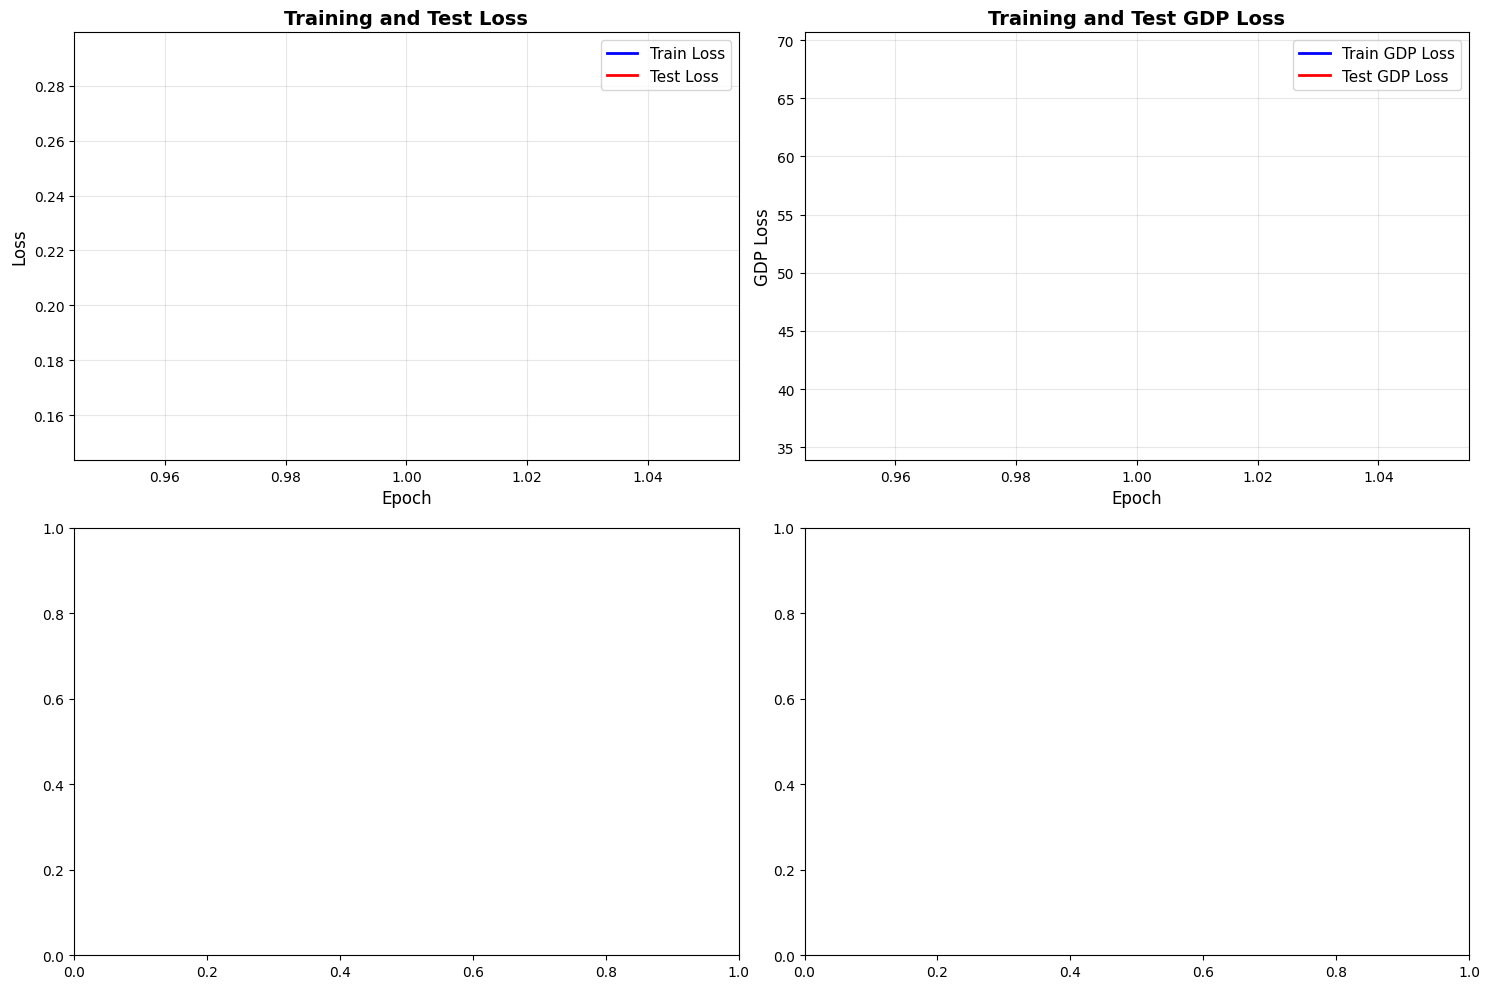

Predictions plot saved to: ../../checkpoints_improved_mlp/MLPdatalightsmsq13-19_predictions.png


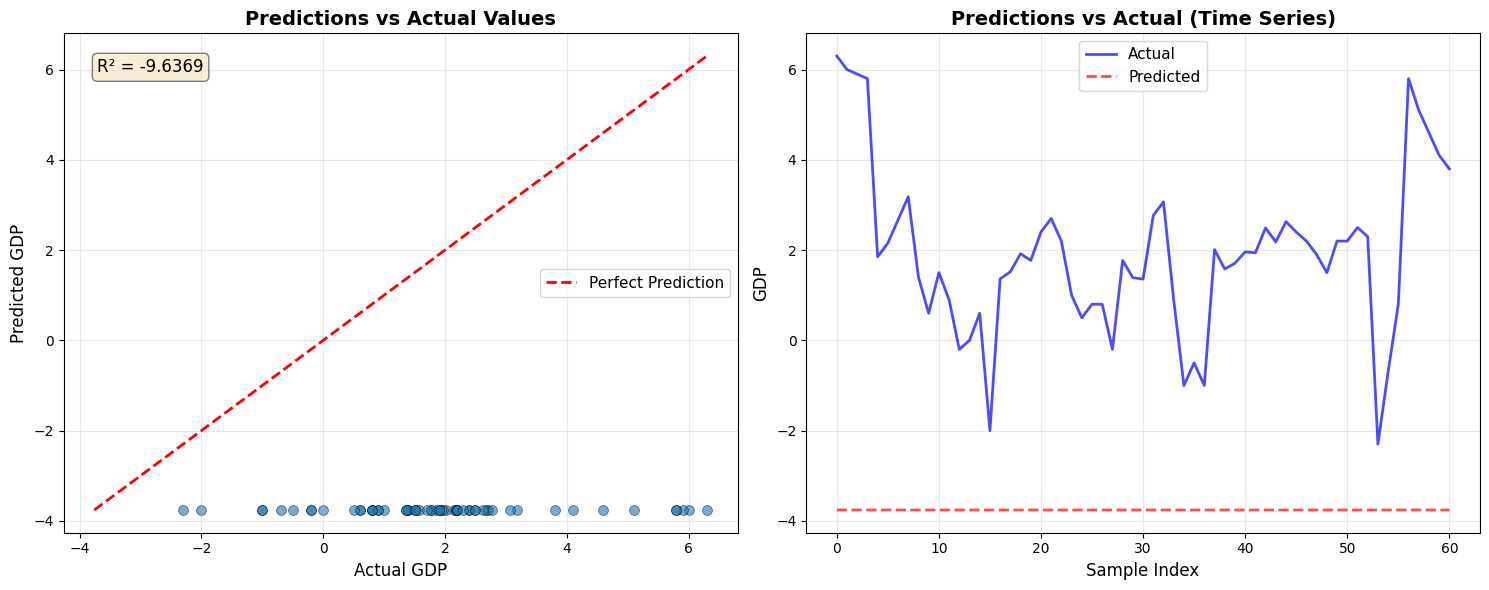

Residual plot saved to: ../../checkpoints_improved_mlp/MLPdatalightsmsq13-19_residuals.png


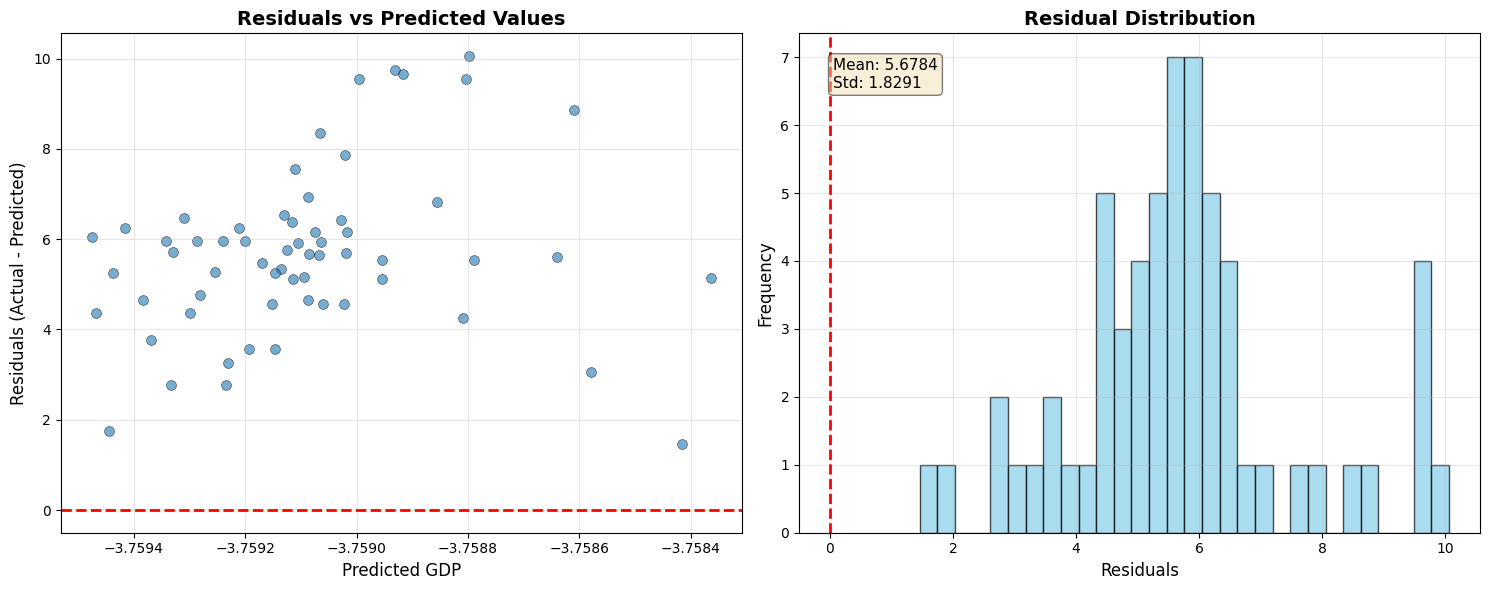

⚠️  Skipping metrics summary - no valid metrics available

✅ All visualizations created and saved!

✅ Visualization generation complete!


In [10]:
# ============================================================================
# GENERATE VISUALIZATIONS FOR TRAINED MODELS
# ============================================================================
# Run this cell after training to generate charts for all trained models

import glob
import pickle

config = CONFIG
checkpoint_dir = config.get("checkpoint_dir", "../../checkpoints_improved_mlp/")
data_dir = config["dataset_path"]

# Find all result files
result_files = glob.glob(os.path.join(checkpoint_dir, "*_best_params_res.csv"))

if not result_files:
    print(f"⚠️  No result files found in {checkpoint_dir}")
    print("   Make sure you have run the training first.")
else:
    print(f"Found {len(result_files)} result file(s)")
    print("="*60)
    
    for result_file in result_files:
        # Extract file item name from result file
        file_item = os.path.basename(result_file)
        file_item_clean = file_item.replace("_best_params_res.csv", "").replace("_", "")
        
        # Try to find corresponding history file (if saved)
        history_file = result_file.replace("_best_params_res.csv", "_history.pkl")
        
        if os.path.exists(history_file):
            # Load history from saved file
            with open(history_file, 'rb') as f:
                history = pickle.load(f)
            
            print(f"\nGenerating visualizations for: {file_item_clean}")
            print("-"*60)
            
            # Extract data from history
            preds = history.get("preds", [])
            trues = history.get("trues", [])
            final_metrics = history.get("final_metrics", {})
            
            # Generate visualizations
            create_all_visualizations(
                history,
                preds,
                trues,
                final_metrics,
                checkpoint_dir,
                file_item_clean
            )
        else:
            # Try to reconstruct from CSV result file
            print(f"\n⚠️  History file not found for {file_item_clean}")
            print("   Visualizations may be limited. Re-run training to save full history.")
            
            # Load result CSV to get basic info
            try:
                result_df = pd.read_csv(result_file)
                print(f"   Found result file with metrics:")
                for col in ['final_model_mae', 'final_model_mse', 'final_model_rmse', 'final_model_mape']:
                    if col in result_df.columns:
                        print(f"   {col}: {result_df[col].values[0]}")
            except Exception as e:
                print(f"   Could not load result file: {e}")

print("\n" + "="*60)
print("✅ Visualization generation complete!")
print("="*60)
